In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")


import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout 
from tensorflow.keras.activations import linear, relu, sigmoid 
from tensorflow.keras.losses import SparseCategoricalCrossentropy 
from tensorflow.keras.optimizers import Adam 

import logging 
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

In [17]:
from sklearn.datasets import fetch_openml

data = fetch_openml(name="mnist_784", as_frame=True).frame
pd.DataFrame(data)

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,pixel15,pixel16,pixel17,pixel18,pixel19,pixel20,pixel21,pixel22,pixel23,pixel24,pixel25,pixel26,pixel27,pixel28,pixel29,pixel30,pixel31,pixel32,pixel33,pixel34,pixel35,pixel36,pixel37,pixel38,pixel39,pixel40,...,pixel746,pixel747,pixel748,pixel749,pixel750,pixel751,pixel752,pixel753,pixel754,pixel755,pixel756,pixel757,pixel758,pixel759,pixel760,pixel761,pixel762,pixel763,pixel764,pixel765,pixel766,pixel767,pixel768,pixel769,pixel770,pixel771,pixel772,pixel773,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784,class
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,252,42,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2
69996,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3
69997,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4
69998,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5


In [11]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print(X_train.shape)
print(y_train.shape)

(60000, 28, 28)
(60000,)


In [39]:
from tensorflow.keras.layers import Normalization 
norm = Normalization(axis=-1)
norm.adapt(X_train)
X_train_norm = norm(X_train)
X_test_norm = norm(X_test)

In [13]:
X_train_norm[:1]

<tf.Tensor: shape=(1, 28, 28), dtype=float32, numpy=
array([[[-3.00378073e-03, -9.90672503e-03, -2.82518901e-02,
         -6.25000969e-02, -1.22940026e-01, -2.05001697e-01,
         -2.91478753e-01, -3.82064581e-01, -4.71989334e-01,
         -5.52380562e-01, -6.13040090e-01, -6.52620554e-01,
         -6.85098946e-01, -7.20983446e-01, -7.46474326e-01,
         -7.58817196e-01, -7.45869696e-01, -7.08649516e-01,
         -6.42558217e-01, -5.52513421e-01, -4.53866810e-01,
         -3.59425962e-01, -2.74555147e-01, -1.97784945e-01,
         -1.27221674e-01, -6.60565943e-02, -2.81418096e-02,
         -7.88947754e-03],
        [-3.00378073e-03, -9.90672503e-03, -2.82518901e-02,
         -6.25000969e-02, -1.22940026e-01, -2.05001697e-01,
         -2.91478753e-01, -3.82064581e-01, -4.71989334e-01,
         -5.52380562e-01, -6.13040090e-01, -6.52620554e-01,
         -6.85098946e-01, -7.20983446e-01, -7.46474326e-01,
         -7.58817196e-01, -7.45869696e-01, -7.08649516e-01,
         -6.42558217

In [14]:
y_train[:1]

array([5], dtype=uint8)

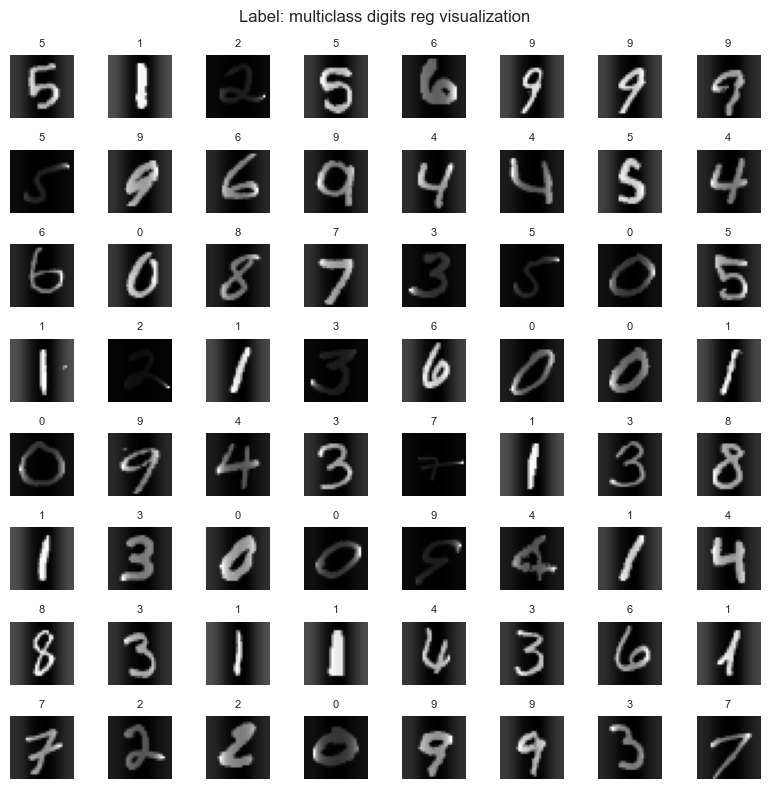

In [33]:
import warnings 
warnings.simplefilter(action="ignore", category="FutureWarning")

m, _ , _ = X_train_norm.shape 
fig, axes = plt.subplots(8,8, figsize=(8,8))

for i, ax in enumerate(axes.flat):
    random_index = np.random.randint(m)
    X_random_reshaped = X_train_norm[random_index]

    ax.imshow(X_random_reshaped, cmap="gray")
    ax.set_title(y_train[random_index], fontsize=8)
    ax.set_axis_off()

fig.suptitle("Label: multiclass digits reg visualization")
plt.tight_layout()
plt.show()

In [34]:
model = Sequential(
    [
        Input((28,28)),
        Flatten(),
        Dense(25, activation="relu"),
        Dense(15, activation="relu"),
        Dropout(0.2),
        Dense(10, activation="linear")
    ]
)

In [40]:

model.compile(loss=SparseCategoricalCrossentropy(from_logits=True), optimizer=Adam(learning_rate=0.001))
model.fit(X_train_norm, y_train, epochs=10)

Epoch 1/10


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 736us/step - loss: 0.1191
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 692us/step - loss: 0.1184
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 664us/step - loss: 0.1163
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 669us/step - loss: 0.1122
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 676us/step - loss: 0.1108
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 667us/step - loss: 0.1105
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 667us/step - loss: 0.1099
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 668us/step - loss: 0.1075
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 666us/step - loss: 0.1069
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 658us/step - loss: 0.1062


In [41]:
model.evaluate(X_test_norm, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 628us/step - loss: 0.1976


0.1976471245288849

In [42]:
pred = model.predict(X_train_norm)

print(pred[:1])

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 512us/step
[[-71.17018    4.802442 -36.725018  15.091877 -22.348463  21.85176
  -27.765154 -28.44319   -8.858878   9.153624]]


In [45]:
sfm = tf.nn.softmax(pred[:1]).numpy()
np.sum(sfm)

1.0000001

In [46]:
print(np.argmax(sfm))

5


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━

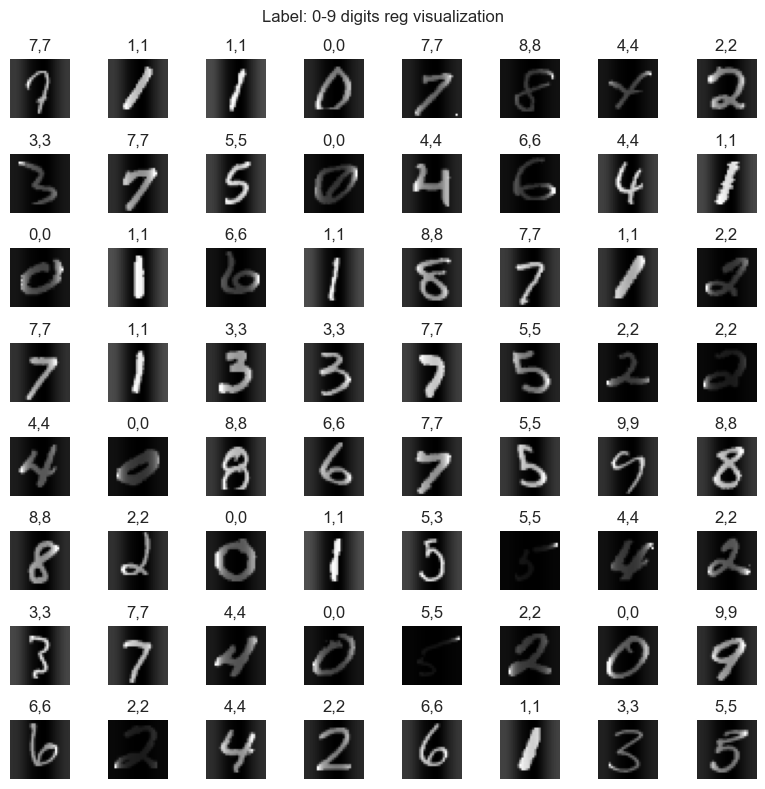

In [53]:
import warnings
warnings.simplefilter(action="ignore", category="FutureWarning")

m, _, _ = X_train_norm.shape
fig, axes = plt.subplots(8,8, figsize=(8,8))

for i, ax in enumerate(axes.flat):
    random_index = np.random.randint(m)

    X_train_reshaped = X_train_norm[random_index]
    ax.imshow(X_train_reshaped, cmap="gray")
    
    sample = X_train_norm[random_index].numpy().reshape(1, 28, 28)
    pred = model.predict(sample)    

    prediction = np.argmax(tf.nn.softmax(pred))

    ax.set_title(f"{y_train[random_index]},{prediction}")
    ax.set_axis_off()

fig.suptitle("Label: 0-9 digits reg visualization")
plt.tight_layout()
plt.show()
